[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter8_seminar_notebook.ipynb)

# Statistics of Financial Markets — Seminar 8: Volatility estimators and volatility clustering

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 8: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with inference and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_8'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Returns and adjusted OHLC prices; rolling and EWMA volatility; the five range-based estimators; ACF, Ljung–Box and ARCH-LM tests; next-day variance forecasts, MSE and QLIKE losses, Mincer–Zarnowitz and Diebold–Mariano.
- Helpers for Part A: historical volatility from a few returns, EWMA step by step, estimators from OHLC prices, Ljung–Box and ARCH-LM from given numbers, losses by hand.

In [ ]:
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom', 'brd': 'BRD', 'tgn': 'Transgaz', 'vix': 'VIX'}
START = {'sp500': '1990-01-01', 'dax': '1990-01-01', 'bet': '1997-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01', 'brd': '2010-01-01', 'tgn': '2010-01-01'}
OHLC_START = {'sp500': '2008-01-01', 'dax': '2006-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01', 'brd': '2010-01-01', 'tgn': '2010-01-01'}
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
ASSETS = ['sp500', 'dax', 'bet', 'btc']
STOCKS = ['tlv', 'snp']
BVB = ['tlv', 'snp', 'brd', 'tgn']
OHLC_ASSETS = ['sp500', 'dax', 'btc', 'tlv', 'snp']
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'snp': '#2E7D32', 'brd': '#8E44AD', 'tlv': '#E67E22', 'tgn': '#DC3545'}
EST_COLORS = {'cc': '#1A3A6E', 'park': '#CD0000', 'gk': '#2E7D32', 'rs': '#E67E22', 'yz': '#8E44AD'}
EST_LABEL = {'cc': 'Close-to-close', 'park': 'Parkinson', 'gk': 'Garman-Klass', 'rs': 'Rogers-Satchell', 'yz': 'Yang-Zhang'}
WINDOWS = (21, 63, 252)
LAMBDAS = (0.94, 0.97)
LB_LAGS = 10
ARCH_LAGS = 5
OOS_START = '2010-01-01'
SEED = 2026
GHOST = ('2019-10-01', '2021-03-31')


def returns(k, start=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k))
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def ohlc(k, start=None):
    """Open, high, low and close prices. Stocks: all four prices multiplied by adjusted_close / close (dividends and
    splits); indices and crypto: as quoted. Weekend quotes and days without trading (close unchanged and high = low)
    are dropped, except for crypto; inconsistent rows (high below open or close, low above them) are dropped."""
    symbol, _, group, field, start0 = SERIES[k]
    t = read_market(symbol).loc[(start or OHLC_START.get(k) or start0):END]
    t = t[['open', 'high', 'low', 'close', 'adjusted_close']].apply(pd.to_numeric, errors='coerce').dropna()
    t = t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)]
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
        t = t[~((t['close'].diff() == 0) & (t['high'] == t['low']))]
    if field == 'adjusted_close':
        f = t['adjusted_close'] / t['close']
        t[['open', 'high', 'low', 'close']] = t[['open', 'high', 'low', 'close']].mul(f, axis=0)
    t = t[(t['high'] >= t[['open', 'close']].max(axis=1)) & (t['low'] <= t[['open', 'close']].min(axis=1))]
    if k in BAD_DAYS:
        t = t.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return t[['open', 'high', 'low', 'close']]


def ann(r):
    """Annualisation factor: the actual number of observations per year (about 252 for stocks, 365 for Bitcoin)."""
    return periods_per_year(r)


def rolling_vol(r, n, a=None):
    """Annualised rolling volatility: sample standard deviation of the last n returns (ddof = 1) times sqrt(a)."""
    a = a or ann(r)
    return r.rolling(n).std() * np.sqrt(a)


def ewma_var(r, lam=0.94, n0=30):
    """EWMA variance sigma2[t] = lam sigma2[t-1] + (1 - lam) r[t-1]^2 (zero mean, RiskMetrics); sigma2[t] uses returns
    up to day t-1, so it is the forecast for day t. Started with the mean of the first n0 squared returns."""
    x = np.asarray(r, float)
    s2 = np.empty(len(x) + 1)
    s2[0] = np.mean(x[:n0] ** 2)
    for t in range(len(x)):
        s2[t + 1] = lam * s2[t] + (1 - lam) * x[t] ** 2
    return s2           # s2[t] = forecast for day t (t = 0..T), s2[T] = forecast for the day after the sample


def ewma_series(r, lam=0.94):
    """EWMA variance known at the close of each day (includes that day's return): forecast for the next day."""
    return pd.Series(ewma_var(r, lam)[1:], index=r.index)


def ewma_facts(lams=LAMBDAS):
    """Half-life ln(0.5)/ln(lam), mean lag 1/(1 - lam) and the number of days that carry 99% of the weight."""
    return {str(l): {'half_life': np.log(0.5) / np.log(l), 'mean_lag': 1 / (1 - l), 'days99': np.log(0.01) / np.log(l),
                     'w1': 1 - l} for l in lams}


def range_parts(t):
    """Log components in %: o = overnight ln(O_t / C_t-1), u = ln(H/O), d = ln(L/O), c = ln(C/O), cc = ln(C_t / C_t-1)."""
    lo, lh, ll, lc = (100 * np.log(t[c]) for c in ['open', 'high', 'low', 'close'])
    return pd.DataFrame({'o': lo - lc.shift(), 'u': lh - lo, 'd': ll - lo, 'c': lc - lo, 'cc': lc - lc.shift()}).dropna()


def daily_estimators(p):
    """One-day variance estimates (%^2): close-to-close cc^2, Parkinson (u - d)^2 / (4 ln 2),
    Garman-Klass 0.5 (u - d)^2 - (2 ln 2 - 1) c^2, Rogers-Satchell u (u - c) + d (d - c)."""
    return pd.DataFrame({'cc': p['cc'] ** 2,
                         'park': (p['u'] - p['d']) ** 2 / (4 * np.log(2)),
                         'gk': 0.5 * (p['u'] - p['d']) ** 2 - (2 * np.log(2) - 1) * p['c'] ** 2,
                         'rs': p['u'] * (p['u'] - p['c']) + p['d'] * (p['d'] - p['c'])}, index=p.index)


def yz_k(n):
    """Yang-Zhang weight k = 0.34 / (1.34 + (n + 1)/(n - 1))."""
    return 0.34 / (1.34 + (n + 1) / (n - 1))


def window_estimators(p):
    """Variance estimates (%^2 per day) from one window of n days: close-to-close sample variance, the means of the
    Parkinson, Garman-Klass and Rogers-Satchell terms, and Yang-Zhang
    s2_O + k s2_C + (1 - k) s2_RS (s2_O, s2_C: sample variances of the overnight and open-to-close returns)."""
    n = len(p)
    de = daily_estimators(p)
    k = yz_k(n)
    yz = p['o'].var(ddof=1) + k * p['c'].var(ddof=1) + (1 - k) * de['rs'].mean()
    return {'cc': p['cc'].var(ddof=1), 'park': de['park'].mean(), 'gk': de['gk'].mean(), 'rs': de['rs'].mean(), 'yz': yz}


def rolling_estimators(p, n=21):
    """Rolling n-day variance estimates (%^2 per day) for the five estimators."""
    de = daily_estimators(p)
    k = yz_k(n)
    yz = p['o'].rolling(n).var() + k * p['c'].rolling(n).var() + (1 - k) * de['rs'].rolling(n).mean()
    return pd.DataFrame({'cc': p['cc'].rolling(n).var(), 'park': de['park'].rolling(n).mean(),
                         'gk': de['gk'].rolling(n).mean(), 'rs': de['rs'].rolling(n).mean(), 'yz': yz}).dropna()


def acf(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags) = sum (x_t - m)(x_{t-k} - m) / sum (x_t - m)^2."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def ljung_box(x, m=LB_LAGS):
    """Ljung-Box Q(m) = T(T+2) sum_{k=1}^m rho_hat(k)^2 / (T-k) and its chi-square(m) p-value; applied to squared
    returns it is the McLeod-Li test of ARCH effects."""
    x = np.asarray(x, float)
    T = len(x)
    rho = acf(x, m)
    q = T * (T + 2) * np.sum(rho ** 2 / (T - np.arange(1, m + 1)))
    return {'q': float(q), 'p': float(stats.chi2.sf(q, m)), 'crit': float(stats.chi2.ppf(0.95, m))}


def arch_lm(x, q=ARCH_LAGS):
    """Engle's (1982) ARCH-LM test: regress e_t^2 on a constant and e_{t-1}^2, ..., e_{t-q}^2 (e_t = x_t - mean);
    LM = n R^2 ~ chi-square(q) under no ARCH effects (n = number of regression observations)."""
    e2 = (np.asarray(x, float) - np.mean(x)) ** 2
    y = e2[q:]
    X = np.column_stack([np.ones(len(y))] + [e2[q - j:len(e2) - j] for j in range(1, q + 1)])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    u = y - X @ b
    r2 = 1 - np.sum(u ** 2) / np.sum((y - y.mean()) ** 2)
    lm = len(y) * r2
    return {'lm': float(lm), 'r2': float(r2), 'n': len(y), 'p': float(stats.chi2.sf(lm, q)),
            'crit': float(stats.chi2.ppf(0.95, q)), 'b': b.tolist()}


def ols(y, x):
    """OLS of y on a constant and x: intercept, slope, R^2."""
    X = np.column_stack([np.ones(len(x)), x])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    u = y - X @ b
    return {'a': float(b[0]), 'b': float(b[1]), 'r2': float(1 - np.sum(u ** 2) / np.sum((y - np.mean(y)) ** 2))}


def forecasts(k='sp500', start=OOS_START, windows=WINDOWS, lams=LAMBDAS, with_vix=True, with_range=True):
    """Next-day variance forecasts (%^2) made at each close, for the days from `start`: rolling means of squared
    returns (21, 63, 252 days), EWMA (lambda 0.94, 0.97), VIX^2 / a (S&P 500); proxies of the realised variance:
    r^2 and, with OHLC data, the overnight squared return plus the Garman-Klass term."""
    r = returns(k)
    a = ann(r)
    F = pd.DataFrame(index=r.index)
    for n in windows:
        F[f'hist{n}'] = (r ** 2).rolling(n).mean().shift(1)
    for l in lams:
        F[f'ewma{int(round(100 * l))}'] = pd.Series(ewma_var(r, l)[:-1], index=r.index)
    if with_vix and k == 'sp500':
        F['vix'] = (load_close('vix', START['sp500']).reindex(r.index).ffill() ** 2 / a).shift(1)
    F['r2'] = r ** 2
    if with_range and k in OHLC_START:
        p = range_parts(ohlc(k))
        de = daily_estimators(p)
        F['range'] = (p['o'] ** 2 + de['gk']).reindex(r.index)
    return F.loc[start:].dropna(axis=0, how='any')


def losses(F, proxy='r2', methods=None):
    """Mean MSE (proxy - h)^2 and QLIKE proxy/h + ln h of each forecast h (Patton, 2011)."""
    methods = methods or [c for c in F.columns if c not in ('r2', 'range')]
    p = F[proxy]
    out = {}
    for m in methods:
        h = F[m]
        out[m] = {'mse': float(np.mean((p - h) ** 2)), 'qlike': float(np.mean(p / h + np.log(h)))}
    return out


def mz_table(F, methods=None):
    """Mincer-Zarnowitz regressions proxy_t = a + b h_t + u_t: R^2 with the noisy proxy r^2 and with the range proxy."""
    methods = methods or [c for c in F.columns if c not in ('r2', 'range')]
    out = {}
    for m in methods:
        out[m] = {'r2': ols(F['r2'].values, F[m].values)}
        if 'range' in F:
            out[m]['range'] = ols(F['range'].values, F[m].values)
    return out


def dm_test(F, m1, m2, proxy='r2', lags=5):
    """Diebold-Mariano test of equal QLIKE: t statistic of the mean loss difference d_t = L(m1) - L(m2), with a
    Newey-West (Bartlett) variance with `lags` lags; negative t: m1 has the smaller loss."""
    p = F[proxy]
    d = (p / F[m1] + np.log(F[m1])) - (p / F[m2] + np.log(F[m2]))
    d = d.values - d.values.mean()
    T = len(d)
    v = np.sum(d ** 2) / T
    for j in range(1, lags + 1):
        v += 2 * (1 - j / (lags + 1)) * np.sum(d[j:] * d[:-j]) / T
    dbar = float(((p / F[m1] + np.log(F[m1])) - (p / F[m2] + np.log(F[m2]))).mean())
    t = dbar / np.sqrt(v / T)
    return {'d': dbar, 't': float(t), 'p': float(2 * stats.norm.sf(abs(t)))}


def lambda_qlike(k, lams=None, start=None):
    """QLIKE of next-day EWMA forecasts (proxy r^2) as a function of lambda."""
    lams = np.round(np.arange(0.80, 0.996, 0.005), 3) if lams is None else lams
    r = returns(k)
    s = start or max(pd.Timestamp(OOS_START), r.index[0] + pd.DateOffset(years=2))
    p = (r ** 2).loc[s:]
    q = []
    for l in lams:
        h = pd.Series(ewma_var(r, l)[:-1], index=r.index).loc[s:]
        q.append(float(np.mean(p / h + np.log(h))))
    q = np.array(q)
    return pd.Series(q, index=lams)


def hist_vol(r, a=252):
    """Mean, sample standard deviation (ddof = 1), zero-mean volatility sqrt(mean r^2), annualised volatility
    sd sqrt(a) and the relative standard error 1/sqrt(2n) of a sample volatility (Normal returns)."""
    r = np.asarray(r, float)
    n = len(r)
    sd = r.std(ddof=1)
    return {'n': n, 'mean': r.mean(), 'dev2': ((r - r.mean()) ** 2).tolist(), 'ss': float(((r - r.mean()) ** 2).sum()),
            'var': sd ** 2, 'sd': sd, 'sd0': np.sqrt(np.mean(r ** 2)), 'ann': sd * np.sqrt(a), 'a': a,
            'rse': 1 / np.sqrt(2 * n), 'lo': sd * np.sqrt(a) * (1 - 1.96 / np.sqrt(2 * n)),
            'hi': sd * np.sqrt(a) * (1 + 1.96 / np.sqrt(2 * n))}


def ewma_steps(r, lam=0.94, s0=1.0, a=252):
    """EWMA recursion sigma2_t = lam sigma2_{t-1} + (1 - lam) r_{t-1}^2, from sigma2_0 = s0 (%^2); annualised
    volatility of the last value; half-life and the number of days with 99% of the weight."""
    s = [s0]
    for x in r:
        s.append(lam * s[-1] + (1 - lam) * x ** 2)
    f = ewma_facts([lam])[str(lam)]
    return {'s2': s, 'vol': [np.sqrt(v) for v in s], 'ann_last': np.sqrt(s[-1] * a), **f}


def ohlc_one_day(prev_close, o, h, l, c, a=252):
    """Log components in % and the one-day estimates (%^2) of a single trading day; annualised volatilities."""
    lo, lh, ll, lc, lp = (100 * np.log(x) for x in (o, h, l, c, prev_close))
    p = {'o': lo - lp, 'u': lh - lo, 'd': ll - lo, 'c': lc - lo, 'cc': lc - lp}
    e = {'cc': p['cc'] ** 2, 'park': (p['u'] - p['d']) ** 2 / (4 * np.log(2)),
         'gk': 0.5 * (p['u'] - p['d']) ** 2 - (2 * np.log(2) - 1) * p['c'] ** 2,
         'rs': p['u'] * (p['u'] - p['c']) + p['d'] * (p['d'] - p['c'])}
    return {**p, 'est': e, 'ann': {k: np.sqrt(max(v, 0) * a) for k, v in e.items()}, 'hl': p['u'] - p['d']}


def ohlc_days(rows, prev_close, a=252):
    """Several days (rows of open, high, low, close): daily components, the five window estimates (%^2 per day),
    the Yang-Zhang weight k and the annualised volatilities."""
    t = pd.DataFrame(rows, columns=['open', 'high', 'low', 'close'])
    t = pd.concat([pd.DataFrame([[np.nan, np.nan, np.nan, prev_close]], columns=t.columns), t], ignore_index=True)
    p = range_parts(t)
    de = daily_estimators(p)
    w = window_estimators(p)
    return {'parts': p.round(4).to_dict('list'), 'daily': de.round(4).to_dict('list'), 'k': yz_k(len(p)),
            's2_o': p['o'].var(ddof=1), 's2_c': p['c'].var(ddof=1), 'est': w,
            'ann': {k: np.sqrt(max(v, 0) * a) for k, v in w.items()}}


def clustering_from_acf(rho, T, r2=None, n=None, q=5):
    """Ljung-Box statistic of squared returns (McLeod-Li) from given autocorrelations; ARCH-LM = n R^2."""
    rho = np.asarray(rho, float)
    m = len(rho)
    k = np.arange(1, m + 1)
    terms = T * (T + 2) * rho ** 2 / (T - k)
    out = {'terms': terms.tolist(), 'lb': float(terms.sum()), 'crit_lb': float(stats.chi2.ppf(0.95, m)),
           'p_lb': float(stats.chi2.sf(terms.sum(), m))}
    if r2 is not None:
        lm = n * r2
        out.update(lm=lm, crit_lm=float(stats.chi2.ppf(0.95, q)), p_lm=float(stats.chi2.sf(lm, q)))
    return out


def losses_by_hand(proxy, fc):
    """Squared errors, QLIKE terms p/h + ln h and their means for each forecast."""
    p = np.asarray(proxy, float)
    out = {}
    for name, h in fc.items():
        h = np.asarray(h, float)
        se, ql = (p - h) ** 2, p / h + np.log(h)
        out[name] = {'se': se.tolist(), 'ql': ql.tolist(), 'mse': float(se.mean()), 'qlike': float(ql.mean())}
    return out

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: historical volatility from five days

**Context.** Daily returns (%) of a stock: 1.2, −0.8, 0.5, −1.5, 0.6.

1. Compute the mean and the sample standard deviation (divide by $n - 1$).
2. Annualise the standard deviation with $a = 252$.
3. Compute the zero-mean volatility $\sqrt{\frac{1}{n}\sum r_t^2}$.
4. Compute $1/\sqrt{2n}$ and an approximate 95% interval for the annual volatility.

**Report:** the mean, two daily volatilities, one annual volatility, one interval and one sentence.

In [6]:
# Solution
pd.Series(hist_vol([1.2, -0.8, 0.5, -1.5, 0.6]))

n                                                  5
mean                                            -0.0
dev2    [1.44, 0.6400000000000001, 0.25, 2.25, 0.36]
ss                                              4.94
var                                            1.235
sd                                          1.111306
sd0                                         0.993982
ann                                        17.641429
a                                                252
rse                                         0.316228
lo                                          6.707158
hi                                         28.575699
dtype: object

**Interpretation of the result.** Five days say almost nothing: the 95% interval for the annual volatility is very wide.

## A2 [Proposed]: Bitcoin over six days

**Context.** Daily Bitcoin returns (%): 3.1, −4.2, 1.0, 5.5, −2.4, −0.9. Model: A1.

1. Compute the mean and the sample standard deviation.
2. Annualise it with $a = 365$ and, wrongly, with $a = 252$.
3. Compute the approximate 95% interval for the annual volatility ($a = 365$).

**Report:** two annual volatilities, one interval and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: EWMA step by step

**Context.** $\lambda = 0.94$; today's EWMA variance is $\sigma_1^2 = 1.00$ (%²); the next three returns are $r_1 = -2.0\%$, $r_2 = 0.5\%$, $r_3 = 3.0\%$.

1. Compute $\sigma_2^2$, $\sigma_3^2$ and $\sigma_4^2$.
2. Annualise $\sigma_4$ with $a = 252$.
3. Compute the half-life and the weight of $r_3^2$ in $\sigma_4^2$.

**Report:** three variances, one annual volatility, the half-life and one sentence.

In [8]:
# Solution
ewma_steps([-2.0, 0.5, 3.0], 0.94, 1.0)

{'s2': [1.0, 1.1800000000000002, 1.1242, 1.5967480000000005],
 'vol': [np.float64(1.0),
  np.float64(1.0862780491200217),
  np.float64(1.0602829810951415),
  np.float64(1.263624944356513)],
 'ann_last': np.float64(20.059424119350986),
 'half_life': np.float64(11.202305583621158),
 'mean_lag': 16.666666666666654,
 'days99': np.float64(74.42650729148939),
 'w1': 0.06000000000000005}

**Interpretation of the result.** One 3% day raises the variance by about 42%; a quiet day lowers it by only 6%.

## A4 [Proposed]: a slower EWMA

**Context.** The same data as A3, with $\lambda = 0.97$ (the RiskMetrics monthly value). Model: A3.

1. Compute $\sigma_2^2$, $\sigma_3^2$ and $\sigma_4^2$ and annualise $\sigma_4$.
2. Compute the half-life and the number of days that carry 99% of the weight.
3. Compare with A3: which $\lambda$ reacts faster to the 3% day?

**Report:** three variances, one annual volatility, two numbers of days and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: four estimators from one day

**Context.** Previous close 100.0; open 101.0, high 103.5, low 99.8, close 102.2.

1. Compute $o$, $u$, $d$, $c$ (in %) and $r = o + c$.
2. Compute the one-day CC, Parkinson, Garman–Klass and Rogers–Satchell variances.
3. Annualise each with $a = 252$, as if every day looked like this one.
4. Say which estimators see the overnight move $o$.

**Report:** five log returns, four variances, four annual volatilities and one sentence.

In [10]:
# Solution
ohlc_one_day(100.0, 101.0, 103.5, 99.8, 102.2)

{'o': np.float64(0.9950330853168339),
 'u': np.float64(2.445109586416322),
 'd': np.float64(-1.1952333523841503),
 'c': np.float64(1.1811160928343725),
 'cc': np.float64(2.1761491781512063),
 'est': {'cc': np.float64(4.735625245568171),
  'park': np.float64(4.77968355197269),
  'gk': np.float64(6.087154115151784),
  'rs': np.float64(5.930894722169834)},
 'ann': {'cc': np.float64(34.54529724699412),
  'park': np.float64(34.70562281672982),
  'gk': np.float64(39.16583762691983),
  'rs': np.float64(38.659868985639335)},
 'hl': np.float64(3.6403429388004724)}

**Interpretation of the result.** Only close-to-close (and Yang–Zhang, on several days) include the overnight move; Parkinson, Garman–Klass and Rogers–Satchell see only the trading session.

## A6 [Proposed]: three days and the Yang–Zhang estimator

**Context.** Previous close 50.0; open, high, low, close of three days: (50.2, 51.0, 49.6, 50.8), (50.5, 51.9, 50.3, 51.6), (51.9, 52.4, 50.9, 51.1). Model: A5.

1. Compute $o$, $u$, $d$, $c$ for each day.
2. Compute the Parkinson and Rogers–Satchell terms of each day and their means.
3. Compute $k$, $\hat\sigma_O^2$, $\hat\sigma_C^2$ and the Yang–Zhang variance for $n = 3$.
4. Compare with the CC sample variance and annualise all three with $a = 252$.

**Report:** a small table, three variances, three annual volatilities and one sentence.

In [ ]:
# Your code here


## A7 [Solved]: two tests for clustering

**Context.** $T = 1000$ daily returns; the ACF of the squared returns at lags 1–5: 0.20, 0.15, 0.12, 0.10, 0.08; the ARCH-LM regression with $q = 5$ lags on $n = 995$ observations has $R^2 = 0.08$.

1. Compute the Ljung–Box statistic $Q(5)$ of the squared returns.
2. Compute $\mathrm{LM} = nR^2$.
3. Compare both with $\chi^2_{0.95}(5) = 11.07$ and decide.

**Report:** two statistics, two decisions and one sentence.

In [12]:
# Solution
clustering_from_acf([0.20, 0.15, 0.12, 0.10, 0.08], 1000, r2=0.08, n=995)

{'terms': [40.12012012012013,
  22.590180360721444,
  14.472216649949848,
  10.060240963855424,
  6.445025125628141],
 'lb': 93.68778322027497,
 'crit_lb': 11.070497693516351,
 'p_lb': 1.1275364052395117e-18,
 'lm': 79.60000000000001,
 'crit_lm': 11.070497693516351,
 'p_lm': 1.0174913397085063e-15}

**Interpretation of the result.** Both statistics are far above the critical value: the variance is predictable from the recent past.

## A8 [Proposed]: when the two tests disagree

**Context.** $T = 500$; ACF of the squared returns at lags 1–5: 0.12, 0.08, 0.06, 0.05, 0.04; ARCH-LM with $q = 5$ on $n = 495$ observations: $R^2 = 0.018$. Model: A7.

1. Compute $Q(5)$ and decide at 5%.
2. Compute LM and decide at 5%.
3. Give one reason why the two tests can disagree.

**Report:** two statistics, two decisions and one sentence.

In [ ]:
# Your code here


## A9 [Solved]: MSE and QLIKE by hand

**Context.** Over four days the proxy $r_t^2$ is 1.0, 4.0, 0.25, 2.25 (%²). Forecast A is flat at 1.5; forecast B is 1.0, 2.5, 0.8, 1.8.

1. Compute the MSE of each forecast.
2. Compute the QLIKE terms $r_t^2/h_t + \ln h_t$ and their mean for each forecast.
3. Say which forecast is better under each loss.

**Report:** two MSE values, two QLIKE values and one sentence.

In [14]:
# Solution
losses_by_hand([1.0, 4.0, 0.25, 2.25], {'A': [1.5] * 4, 'B': [1.0, 2.5, 0.8, 1.8]})

{'A': {'se': [0.25, 6.25, 1.5625, 0.5625],
  'ql': [1.0721317747748311,
   3.0721317747748307,
   0.572131774774831,
   1.9054651081081644],
  'mse': 2.15625,
  'qlike': 1.6554651081081642},
 'B': {'se': [0.0, 2.25, 0.30250000000000005, 0.20249999999999996],
  'ql': [1.0, 2.516290731874155, 0.08935644868579029, 1.837786664902119],
  'mse': 0.6887500000000001,
  'qlike': 1.3608584613655161}}

**Interpretation of the result.** B is better under both losses: it follows the changes of the variance.

## A10 [Proposed]: under- and over-prediction

**Context.** The true variance and the proxy are both 1. Two forecasts: $h = 0.5$ (half) and $h = 2$ (double). Model: A9.

1. Compute the MSE of each forecast.
2. Compute the QLIKE of each forecast.
3. Say which loss punishes under-prediction more.

**Report:** four numbers and one sentence on why this matters for VaR.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: historical and EWMA volatility of the S&P 500

**Question.** How different are the 21-, 63- and 252-day and EWMA volatilities of the S&P 500?

1. Compute the rolling 21-, 63- and 252-day volatility and the EWMA volatility ($\lambda = 0.94$), annualised with the actual frequency.
2. Draw the four series since 2018.
3. Report the four values at the end of the sample and their maxima in 2020, with dates.
4. Find the day of June 2020 when the 63-day volatility falls most, and report the change of EWMA on that day.
5. Interpretation: which estimate would you report to a risk committee on that day?

**Report:** the chart, twelve numbers and two sentences.

{'ppy': 251.7274558066682,
 'whole': 17.986746287397747,
 'last': {'21 days': 9.625269592719333,
  '63 days': 11.128742786417243,
  '252 days': 12.89154781528677,
  'EWMA 0.94': 10.389595121790576},
 'last_date': Timestamp('2026-09-18 00:00:00'),
 'max2020': {'21 days': 97.50239715434907,
  '63 days': 62.56584271790131,
  '252 days': 34.73784774266333,
  'EWMA 0.94': 84.7808204943568},
 'max2020_date': {'21 days': Timestamp('2020-04-06 00:00:00'),
  '63 days': Timestamp('2020-05-20 00:00:00'),
  '252 days': Timestamp('2020-12-28 00:00:00'),
  'EWMA 0.94': Timestamp('2020-03-24 00:00:00')},
 'ghost_day': Timestamp('2020-06-15 00:00:00'),
 'ghost_63_before': 50.42499290614944,
 'ghost_63_after': 43.032689947681995,
 'ghost_ewma_before': 35.55517386031438,
 'ghost_ewma_after': 34.62180830031481}

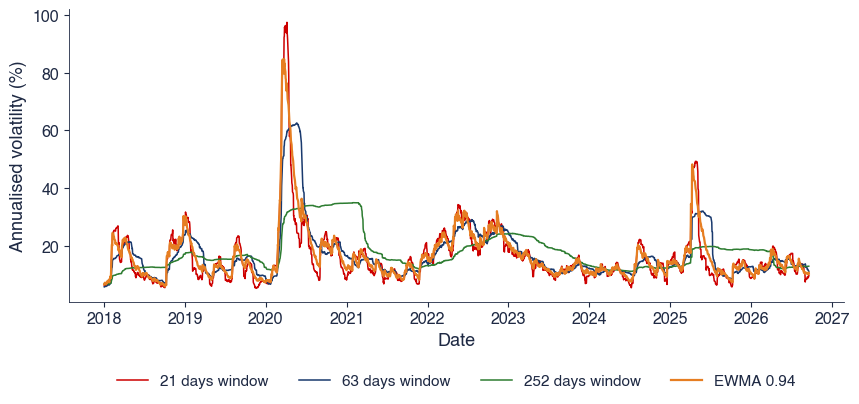

In [16]:
# Solution
def b1_hist(k='sp500', start='2018-01-01', save=True, plot=True):
    """Rolling 21-, 63-, 252-day and EWMA (0.94) volatility of the S&P 500, annualised; values at the end of the
    sample, maxima in 2020 and the ghost effect of June 2020."""
    r = returns(k)
    a = ann(r)
    V = pd.DataFrame({f'{n} days': rolling_vol(r, n, a) for n in (21, 63, 252)})
    V['EWMA 0.94'] = np.sqrt(ewma_series(r, 0.94) * a)
    if plot or save:
        fig, ax = plt.subplots(figsize=(10, 3.8))
        for c, col in zip(V.columns, ['#CD0000', '#1A3A6E', '#2E7D32', '#E67E22']):
            ax.plot(V.loc[start:].index, V.loc[start:, c], color=col, lw=1.6 if c.startswith('EWMA') else 1.1,
                    label=c if c.startswith('EWMA') else f'{c} window')
        ax.set_ylabel('Annualised volatility (%)')
        ax.set_xlabel('Date')
        st.legend_outside_bottom(ax, ncol=4, y=-0.2)
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch8_sem_b1')
    z = V.loc['2020']
    j = V.loc['2020-06-01':'2020-06-30', '63 days'].diff().idxmin()
    return {'ppy': a, 'whole': float(r.std() * np.sqrt(a)), 'last': V.iloc[-1].to_dict(), 'last_date': V.index[-1],
            'max2020': z.max().to_dict(), 'max2020_date': {c: z[c].idxmax() for c in V.columns},
            'ghost_day': j, 'ghost_63_before': float(V['63 days'].shift().loc[j]), 'ghost_63_after': float(V.loc[j, '63 days']),
            'ghost_ewma_before': float(V['EWMA 0.94'].shift().loc[j]), 'ghost_ewma_after': float(V.loc[j, 'EWMA 0.94'])}


b1 = b1_hist(save=False)
b1

**Interpretation of the result.** EWMA: the drop of the 63-day estimate in June 2020 is the ghost effect of the crash days leaving the window, not news.

## B2 [Proposed]: BET and Bitcoin

**Question.** How volatile are the BET and Bitcoin compared with the S&P 500, today and at the end of 2017? Model: B1.

1. Compute the number of observations per year and the whole-sample annual volatility of each series.
2. Annualise Bitcoin also with 252 and give the error in %.
3. Report the 252-day volatility at the end of 2017 and at the end of the sample, and the maximum of the 63-day volatility with its year.
4. Interpretation: has Bitcoin become an asset with equity-like volatility?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: range-based estimators for the S&P 500

**Question.** Do range-based estimators give the same volatility as closing prices for the S&P 500?

1. Compute $o_t$, $u_t$, $d_t$, $c_t$ and the five estimators on the whole sample, annualised.
2. Decompose $\mathrm{Var}(r_t) = \mathrm{Var}(o_t) + \mathrm{Var}(c_t) + 2\,\mathrm{Cov}(o_t, c_t)$.
3. Draw the rolling 21-day estimates since 2025.
4. Interpretation: why are Parkinson, Garman–Klass and Rogers–Satchell below close-to-close?

**Report:** the chart, five volatilities, a decomposition and two sentences.

{'n': 4707,
 'first': Timestamp('2008-01-03 00:00:00'),
 'ppy': 251.60716376408604,
 'ann': {'cc': 19.85992382396396,
  'park': 15.417801837532012,
  'gk': 14.611180984341468,
  'rs': 14.399478841940157,
  'yz': 16.285432508932967},
 'night_share': 0.12865371098079295,
 'corr_oc': 0.21515886072426935,
 'var_cc': 1.567588809448476,
 'var_o': 0.17627839012862243,
 'var_c': 1.1938988770855312,
 'cov_oc2': 0.19741154223433666}

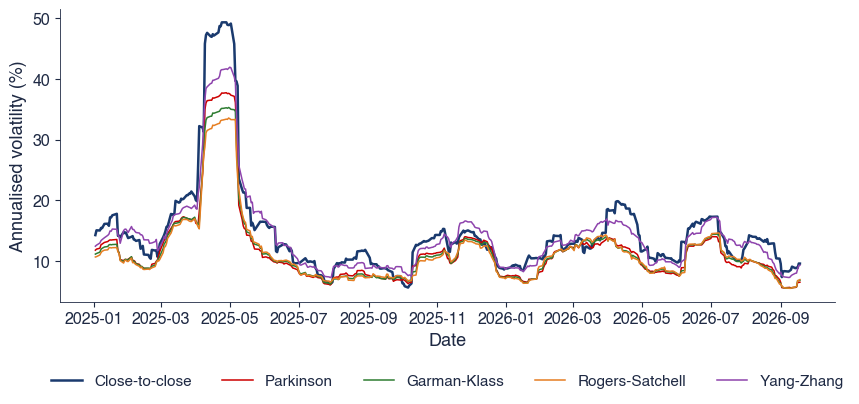

In [18]:
# Solution
def b3_range(k='sp500', start='2025-01-01', save=True, plot=True):
    """Range-based estimators of the S&P 500 since 2008: whole-sample annualised volatility, overnight share of the
    variance, correlation of overnight and open-to-close returns; rolling 21-day estimates (chart)."""
    t = ohlc(k)
    p = range_parts(t)
    a = ann(p['cc'])
    w = window_estimators(p)
    so, sc = p['o'].var(ddof=1), p['c'].var(ddof=1)
    if plot or save:
        R = np.sqrt(rolling_estimators(p, 21).clip(lower=0) * a).loc[start:]
        fig, ax = plt.subplots(figsize=(10, 3.8))
        for e in EST_LABEL:
            ax.plot(R.index, R[e], color=EST_COLORS[e], lw=1.8 if e == 'cc' else 1.1, label=EST_LABEL[e])
        ax.set_ylabel('Annualised volatility (%)')
        ax.set_xlabel('Date')
        st.legend_outside_bottom(ax, ncol=5, y=-0.2)
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch8_sem_b3')
    return {'n': len(p), 'first': p.index[0], 'ppy': a, 'ann': {e: float(np.sqrt(v * a)) for e, v in w.items()},
            'night_share': float(so / (so + sc)), 'corr_oc': float(np.corrcoef(p['o'], p['c'])[0, 1]),
            'var_cc': float(p['cc'].var(ddof=1)), 'var_o': float(so), 'var_c': float(sc),
            'cov_oc2': float(2 * np.cov(p['o'], p['c'])[0, 1])}


b3 = b3_range(save=False)
b3

**Interpretation of the result.** They see only the trading session: they miss the overnight variance and the covariance of overnight and open-to-close returns; Yang–Zhang adds the night but not the covariance.

## B4 [Proposed]: DAX, Bitcoin and TLV

**Question.** For which of the DAX, Bitcoin and Banca Transilvania do range-based estimators agree with close-to-close? Model: B3.

1. Compute the five annualised estimators for each asset.
2. Compute the share of the night and $\mathrm{corr}(o_t, c_t)$.
3. Rank the assets by the ratio Parkinson / CC.
4. Interpretation: for which asset could you replace close-to-close by Parkinson?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: clustering in the S&P 500

**Question.** Are the size and the sign of S&P 500 returns equally predictable?

1. Draw the ACF of $r_t$, $r_t^2$ and $|r_t|$ for lags 1–50 with the i.i.d. 95% band.
2. Report $\hat\rho_1, \dots, \hat\rho_5$ of $r_t$ and of $r_t^2$.
3. Compute the Ljung–Box $Q(10)$ of $r_t$, $r_t^2$ and $|r_t|$, and the ARCH-LM(5) statistic with its $R^2$.
4. Interpretation: does volatility clustering contradict weak-form market efficiency?

**Report:** the chart, ten autocorrelations, four statistics and two sentences.

{'T': 9240,
 'rho_r': [-0.07868231036241596,
  -0.0041494257757456465,
  -0.00618504287606054,
  -0.0224354115805981,
  -0.015800398719636358],
 'rho_r2': [0.3105931079305584,
  0.40822490771223485,
  0.2503379142701023,
  0.29788888330568675,
  0.3077404572266094],
 'rho_abs': [0.27457690681032093,
  0.34316344991294245,
  0.3026701092965396,
  0.3106358592733867,
  0.3235949584437212],
 'lb_r': {'q': 90.75341781486343,
  'p': 3.796466746527177e-15,
  'crit': 18.307038053275146},
 'lb_r2': {'q': 8014.689381207304, 'p': 0.0, 'crit': 18.307038053275146},
 'lb_abs': {'q': 8323.13884037502, 'p': 0.0, 'crit': 18.307038053275146},
 'arch': {'lm': 2227.396308492915,
  'r2': 0.24119072100627126,
  'n': 9235,
  'p': 0.0,
  'crit': 11.070497693516351,
  'b': [0.39470346901002523,
   0.14814093571757675,
   0.2821546358597936,
   0.007481612820972154,
   0.09399137059057477,
   0.16109450936883843]}}

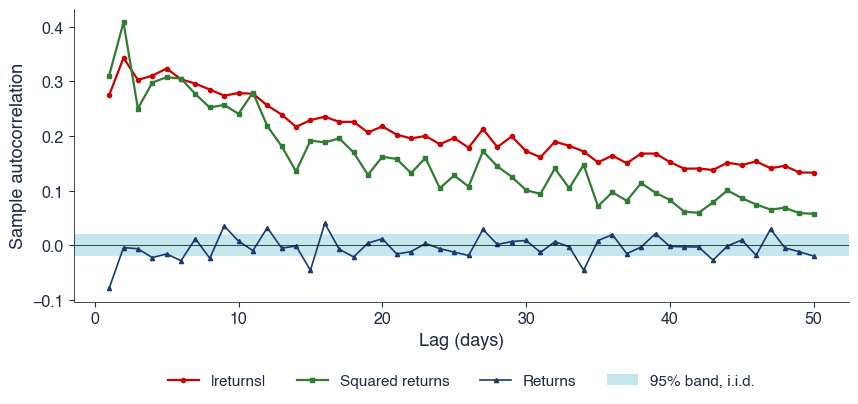

In [20]:
# Solution
def b5_clustering(k='sp500', lags=50, save=True, plot=True):
    """ACF of returns, squared and absolute returns (chart); Ljung-Box Q(10) of the three series; ARCH-LM(5)."""
    x = returns(k).values
    T = len(x)
    if plot or save:
        j = np.arange(1, lags + 1)
        fig, ax = plt.subplots(figsize=(10, 3.8))
        ax.plot(j, acf(np.abs(x), lags), color='#CD0000', lw=1.6, marker='o', ms=3, label='|returns|')
        ax.plot(j, acf(x ** 2, lags), color='#2E7D32', lw=1.6, marker='s', ms=3, label='Squared returns')
        ax.plot(j, acf(x, lags), color='#1A3A6E', lw=1.2, marker='^', ms=3, label='Returns')
        b = 1.96 / np.sqrt(T)
        ax.axhspan(-b, b, color='#17A2B8', alpha=0.25, lw=0, label='95% band, i.i.d.')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_xlabel('Lag (days)')
        ax.set_ylabel('Sample autocorrelation')
        st.legend_outside_bottom(ax, ncol=4, y=-0.2)
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch8_sem_b5')
    return {'T': T, 'rho_r': acf(x, 5).tolist(), 'rho_r2': acf(x ** 2, 5).tolist(), 'rho_abs': acf(np.abs(x), 5).tolist(),
            'lb_r': ljung_box(x), 'lb_r2': ljung_box(x ** 2), 'lb_abs': ljung_box(np.abs(x)), 'arch': arch_lm(x)}


b5 = b5_clustering(save=False)
b5

**Interpretation of the result.** No: the size of returns is predictable, the sign hardly; efficiency is about predictable returns, not about predictable risk (Chapter 7).

## B6 [Proposed]: four more series

**Question.** Does volatility clustering in the BET, Bitcoin, Banca Transilvania and OMV Petrom depend on the order of the days? Model: B5.

1. Compute $\hat\rho_1(r^2)$, $Q(10)$ of $r_t^2$, ARCH-LM(5) and the excess kurtosis of each series.
2. Shuffle the returns at random (seed 2026) and compute $Q(10)$ of $r_t^2$ and ARCH-LM(5) again.
3. Interpretation: why does shuffling remove the clustering but not the heavy tails?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B7 [Solved]: which forecast is best?

**Question.** Which simple forecast of tomorrow's S&P 500 variance has the smallest loss since 2010?

1. Build next-day forecasts: rolling means of $r_t^2$ on 21, 63 and 252 days, EWMA with $\lambda = 0.94$ and $0.97$, and $\mathrm{VIX}^2/a$.
2. Compute MSE and QLIKE with the proxy $r_t^2$.
3. Run the Diebold–Mariano test for EWMA 0.94 against the 21-day window and for the VIX against EWMA 0.94.
4. Draw the QLIKE of EWMA for $\lambda$ from 0.80 to 0.995.
5. Interpretation: is the VIX a better forecast of tomorrow's variance than EWMA?

**Report:** a table of twelve numbers, two tests, the chart and two sentences.

{'best_lambda': 0.925, 'dm_ewma_hist21': {'d': -0.06843568818172104, 't': -4.49577176324768, 'p': 6.93180602566845e-06}, 'dm_vix_ewma': {'d': -0.008341660216265796, 't': -0.316943542616462, 'p': 0.7512864416939319}}


,mse,qlike
hist21,18.9873,0.8761
hist63,20.7651,0.9144
hist252,21.4327,1.0987
ewma94,17.7717,0.8076
ewma97,19.0161,0.8443
vix,16.6974,0.7993


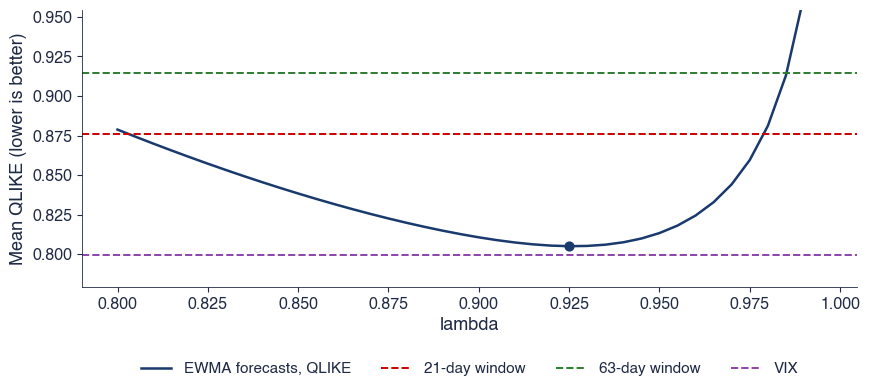

In [22]:
# Solution
def b7_forecast(k='sp500', save=True, plot=True):
    """Next-day variance forecasts of the S&P 500 from 2010: MSE and QLIKE with the proxy r^2; Diebold-Mariano
    tests; QLIKE of EWMA as a function of lambda (chart)."""
    F = forecasts(k, with_range=False)
    L = losses(F, 'r2')
    q = lambda_qlike(k)
    if plot or save:
        fig, ax = plt.subplots(figsize=(10, 3.6))
        ax.plot(q.index, q.values, color='#1A3A6E', lw=1.8, label='EWMA forecasts, QLIKE')
        for m, c in [('hist21', '#CD0000'), ('hist63', '#2E7D32'), ('vix', '#8E44AD')]:
            lab = {'hist21': '21-day window', 'hist63': '63-day window', 'vix': 'VIX'}[m]
            ax.axhline(L[m]['qlike'], color=c, lw=1.4, ls='--', label=lab)
        ax.scatter([q.idxmin()], [q.min()], color='#1A3A6E', s=40, zorder=5)
        ax.set_xlabel('lambda')
        ax.set_ylabel('Mean QLIKE (lower is better)')
        ax.set_ylim(min(q.min(), L['vix']['qlike']) - 0.02, L['hist63']['qlike'] + 0.04)
        st.legend_outside_bottom(ax, ncol=4, y=-0.22)
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch8_sem_b7')
    return {'n': len(F), 'first': F.index[0], 'loss': L, 'best_lambda': float(q.idxmin()), 'best_q': float(q.min()),
            'dm_vix_ewma': dm_test(F, 'vix', 'ewma94'), 'dm_ewma_hist21': dm_test(F, 'ewma94', 'hist21'),
            'dm_ewma97_ewma94': dm_test(F, 'ewma97', 'ewma94')}


b7 = b7_forecast(save=False)
print({c: b7[c] for c in ['best_lambda', 'dm_ewma_hist21', 'dm_vix_ewma']})
pd.DataFrame(b7['loss']).T.round(4)

**Interpretation of the result.** No: the VIX has slightly lower losses than EWMA, but the difference is not significant; both beat the rolling windows.

## B8 [Proposed]: the best $\lambda$ for the BET and Bitcoin

**Question.** Is the RiskMetrics $\lambda = 0.94$ a good choice for the BET and for Bitcoin? Model: B7.

1. Compute the QLIKE of next-day EWMA forecasts for $\lambda$ from 0.80 to 0.995 and find the best $\lambda$.
2. Report the QLIKE at the best $\lambda$, at 0.94 and at 0.97, and the half-life of the best $\lambda$.
3. Run the Diebold–Mariano test of the best $\lambda$ against 0.94.
4. Interpretation: would you use $\lambda = 0.94$ for both series?

**Report:** one table and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: which estimator for BVB stocks?

**Question.** Do range-based estimators improve volatility forecasts for thinly traded stocks of the Bucharest Stock Exchange? Models: B3, B7.

1. Compute the share of trading days with an unchanged close, and the ratios Parkinson / CC and YZ / CC of the whole-sample volatility.
2. Compute the QLIKE (proxy $r_t^2$) of next-day forecasts by the 21-day CC, Parkinson and YZ variances, from 2010.
3. Compare the four stocks with the S&P 500.
4. List two reasons why the best estimator may differ across stocks.
5. Interpretation: what data would you need to explain the differences?

**Report:** a table and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant was asked to summarise the volatility of the S&P 500 and of Bitcoin. It answered:

- (a) since 2008 the Parkinson volatility of the S&P 500 is below the close-to-close volatility; Parkinson is about five times more efficient, so the Parkinson value is the true volatility;
- (b) the Ljung–Box $Q(10)$ of S&P 500 returns has a p-value below 0.001, so the S&P 500 shows volatility clustering;
- (c) EWMA with $\lambda = 0.94$ has a half-life of about 94 days;
- (d) Bitcoin's annual volatility is its daily standard deviation times $\sqrt{252}$;
- (e) since 1990 the VIX was above the realised volatility of the next 21 days on most days.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** five verdicts with one line of justification each.

In [ ]:
# Your code here
